In [78]:

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.impute import KNNImputer

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    accuracy_score,
    precision_recall_curve
)

from imblearn.combine import SMOTETomek

import joblib

import warnings
warnings.filterwarnings("ignore")

plt.style.use("dark_background")

In [79]:
df = pd.read_csv("fraud.csv")

print(df.shape)

df.head()

(7000, 13)


,transaction_amount,hour_of_day,is_weekend,num_items,customer_age,prev_transactions,distance_from_home,device_type,network_quality,is_first_transaction,store_type,velocity_score,is_fraud
0,161.363691,3.0,0.0,2.0,18.000000,2.0,26.539742,1.0,48.403937,0.0,0.0,3.718296,0
1,116.202851,1.0,1.0,4.0,26.285818,2.0,50.714402,NaN,76.144979,0.0,0.0,4.951272,0
2,1.000000,2.0,0.0,5.0,18.000000,NaN,9.467935,0.0,67.600316,0.0,0.0,4.556043,0
3,48.780618,2.0,0.0,3.0,44.471190,NaN,41.077068,0.0,94.825526,0.0,0.0,6.918437,0
4,NaN,3.0,0.0,4.0,38.733609,8.0,NaN,2.0,100.000000,0.0,1.0,5.535335,1


In [80]:
df.info()

print("\nMissing Values:\n")

print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   transaction_amount    6440 non-null   float64
 1   hour_of_day           6650 non-null   float64
 2   is_weekend            6860 non-null   float64
 3   num_items             6790 non-null   float64
 4   customer_age          6160 non-null   float64
 5   prev_transactions     6510 non-null   float64
 6   distance_from_home    6300 non-null   float64
 7   device_type           6720 non-null   float64
 8   network_quality       6370 non-null   float64
 9   is_first_transaction  6790 non-null   float64
 10  store_type            6860 non-null   float64
 11  velocity_score        5950 non-null   float64
 12  is_fraud              7000 non-null   int64  
dtypes: float64(12), int64(1)
memory usage: 711.1 KB

Missing Values:

transaction_amount       560
hour_of_day              350

In [81]:
target = "is_fraud"

print(df[target].value_counts())

print()

print(df[target].value_counts(normalize=True)*100)

is_fraud
0    6279
1     721
Name: count, dtype: int64

is_fraud
0    89.7
1    10.3
Name: proportion, dtype: float64


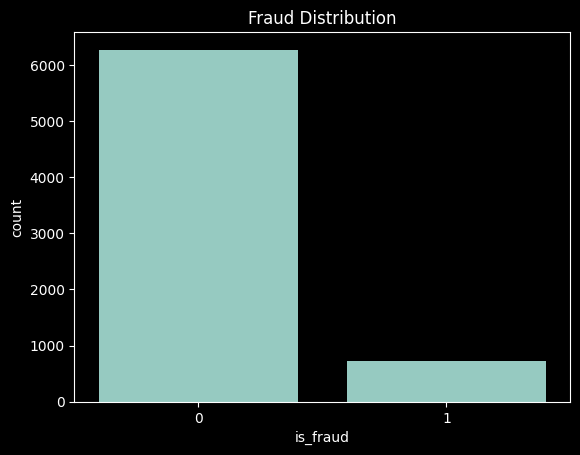

In [82]:
sns.countplot(x=df[target])

plt.title("Fraud Distribution")

plt.show()

In [83]:
X = df.drop("is_fraud", axis=1)

y = df["is_fraud"]

In [84]:
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)

X = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

In [85]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [86]:
from imblearn.combine import SMOTETomek

smote = SMOTETomek(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train,
    y_train
)

print(y_train.value_counts())

print()

print(y_train_resampled.value_counts())

is_fraud
0    5023
1     577
Name: count, dtype: int64

is_fraud
0    4948
1    4948
Name: count, dtype: int64


In [87]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train_resampled,
    y_train_resampled
)

RandomForestClassifier(class_weight='balanced', max_depth=12, n_estimators=300,
                       n_jobs=-1, random_state=42)

In [88]:
pred = model.predict(X_test)

prob = model.predict_proba(X_test)[:,1]

In [89]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

print("Accuracy:", accuracy_score(y_test,pred))

print()

print(confusion_matrix(y_test,pred))

print()

print(classification_report(y_test,pred))

print()

print("ROC-AUC:", roc_auc_score(y_test,prob))

Accuracy: 0.87

[[1217   39]
 [ 143    1]]

              precision    recall  f1-score   support

           0       0.89      0.97      0.93      1256
           1       0.03      0.01      0.01       144

    accuracy                           0.87      1400
   macro avg       0.46      0.49      0.47      1400
weighted avg       0.81      0.87      0.84      1400


ROC-AUC: 0.5208996815286624


In [90]:
import joblib

joblib.dump(model, "fraud_model.pkl")

['fraud_model.pkl']

In [91]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib

model = joblib.load("fraud_model.pkl")

st.title("💳 Fraud Detection System")

transaction_amount = st.number_input("Transaction Amount", value=100.0)

hour_of_day = st.slider("Hour Of Day", 0, 23, 12)

is_weekend = st.selectbox("Is Weekend", [0,1])

num_items = st.number_input("Number Of Items", value=1)

customer_age = st.number_input("Customer Age", value=30)

prev_transactions = st.number_input("Previous Transactions", value=5)

distance_from_home = st.number_input("Distance From Home", value=10.0)

device_type = st.number_input("Device Type", value=0)

network_quality = st.number_input("Network Quality", value=70.0)

is_first_transaction = st.selectbox("First Transaction", [0,1])

store_type = st.number_input("Store Type", value=0)

velocity_score = st.number_input("Velocity Score", value=5.0)

if st.button("Predict"):

    sample = pd.DataFrame({
        "transaction_amount":[transaction_amount],
        "hour_of_day":[hour_of_day],
        "is_weekend":[is_weekend],
        "num_items":[num_items],
        "customer_age":[customer_age],
        "prev_transactions":[prev_transactions],
        "distance_from_home":[distance_from_home],
        "device_type":[device_type],
        "network_quality":[network_quality],
        "is_first_transaction":[is_first_transaction],
        "store_type":[store_type],
        "velocity_score":[velocity_score]
    })

    prediction = model.predict(sample)[0]

    probability = model.predict_proba(sample)[0][1]

    if prediction == 1:
        st.error("🚨 Fraud Transaction")
    else:
        st.success("✅ Legitimate Transaction")

    st.write(f"Fraud Probability: {probability:.2%}")

Overwriting app.py


In [92]:
!pkill -f streamlit

In [93]:
!streamlit run app.py --server.port 8501 > logs.txt 2>&1 &

In [ ]:
!cloudflared tunnel --url http://localhost:8501

2026-06-26T10:56:07Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-06-26T10:56:07Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-06-26T10:56:11Z INF +--------------------------------------------------------------------------------------------+
2026-06-26T10:56:11Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-06-26T10:56:11Z INF |  https://wash-create-sierra-ladies.trycloudflare.com  